<a href="https://colab.research.google.com/github/yiheng870106/-Implied-Volatility-Project/blob/main/Implied_Volatility_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, I will study the implied volatility of options on the S&P 500 index (SPX).

Choose two expiration dates, with roughly one and three months away from the time of observation.

In [22]:
import pandas as pd
pd.set_option('display.width', 200)

In [23]:
# download market data from yfinance
import yfinance as yf

def get_option_chain(ticker_symbol: str, expiry: str = None) -> pd.DataFrame:
    """
    Fetch the option chain for `ticker_symbol` from yfinance.
    If expiry is None, grabs the first available expiration.
    Returns a DataFrame combining calls and puts with an “optionType” column.
    """
    tk = yf.Ticker(ticker_symbol)

    expirations = tk.options
    if not expirations:
        raise ValueError(f"No option expirations found for ticker {ticker_symbol}")

    if expiry is None:
        expiry = expirations[0]

    # fetch
    opt = tk.option_chain(expiry)
    calls = opt.calls.copy()
    puts  = opt.puts.copy()

    calls["optionType"] = "call"
    puts["optionType"]  = "put"

    calls["expiration"] = expiry
    puts["expiration"]  = expiry

    df = pd.concat([calls, puts], ignore_index=True)
    df["underlyingTicker"] = ticker_symbol

    return df

In [24]:
ticker = "SPY"

# current price
S0 = yf.Ticker(ticker).history(period="1d")["Close"].iloc[-1]
date = yf.Ticker(ticker).history(period="1d").index[-1].date()
print(f"Current ({date}) {ticker} price (S0): {S0:.2f}")

# option expirations
tk = yf.Ticker(ticker)
print("option expirations:", tk.options)

Current (2026-05-13) SPY price (S0): 742.31
option expirations: ('2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [25]:
# Choose two expiration dates, with roughly one and three months away from the time of observation
expiry_1M = "2026-06-12"
expiry_3M = "2026-08-21"
df_1M = get_option_chain("SPY", expiry=expiry_1M)

calls_1M = df_1M[df_1M["optionType"] == "call"].copy()
puts_1M = df_1M[df_1M["optionType"] == "put"].copy()
print("expiration date = ", expiry_1M, ":")
print(f"Total options in chain= {len(df_1M)}")
print(f"Total call options in chain= {len(calls_1M)}")
print(f"Total put options in chain= {len(puts_1M)}\n")

df_3M = get_option_chain("SPY", expiry=expiry_3M)

calls_3M = df_3M[df_3M["optionType"] == "call"].copy()
puts_3M = df_3M[df_3M["optionType"] == "put"].copy()
print("expiration date = ", expiry_3M, ":")
print(f"Total options in chain= {len(df_3M)}")
print(f"Total call options in chain= {len(calls_3M)}")
print(f"Total put options in chain= {len(puts_3M)}")

expiration date =  2026-06-12 :
Total options in chain= 243
Total call options in chain= 107
Total put options in chain= 136

expiration date =  2026-08-21 :
Total options in chain= 200
Total call options in chain= 111
Total put options in chain= 89


Select call and put options with strikes surrounding the SPX quote at the time of observation.

In [26]:
calls_1M["moneyness"] = calls_1M["strike"] / S0
calls_1M_near = calls_1M[(calls_1M["moneyness"] >= 0.85) & (calls_1M["moneyness"] <= 1.15)].copy()
calls_1M_near["T"] = (pd.to_datetime(calls_1M_near["expiration"]) - pd.to_datetime(date)).dt.days / 365
print(f"Calls near S0 (expiration={expiry_1M}):")
print(calls_1M_near[["contractSymbol", "strike", "lastPrice", "impliedVolatility", "optionType", "T"]])

puts_1M["moneyness"] = puts_1M["strike"] / S0
puts_1M_near = puts_1M[(puts_1M["moneyness"] >= 0.85) & (puts_1M["moneyness"] <= 1.15)].copy()
puts_1M_near["T"] = (pd.to_datetime(puts_1M_near["expiration"]) - pd.to_datetime(date)).dt.days / 365
print(f"\nPuts near S0 (expiration={expiry_1M}):")
print(puts_1M_near[["contractSymbol", "strike", "lastPrice", "impliedVolatility", "optionType", "T"]])

calls_3M["moneyness"] = calls_3M["strike"] / S0
calls_3M_near = calls_3M[(calls_3M["moneyness"] >= 0.85) & (calls_3M["moneyness"] <= 1.15)].copy()
calls_3M_near["T"] = (pd.to_datetime(calls_3M_near["expiration"]) - pd.to_datetime(date)).dt.days / 365
print(f"\nCalls near S0 (expiration={expiry_3M}):")
print(calls_3M_near[["contractSymbol", "strike", "lastPrice", "impliedVolatility", "optionType", "T"]])

puts_3M["moneyness"] = puts_3M["strike"] / S0
puts_3M_near = puts_3M[(puts_3M["moneyness"] >= 0.85) & (puts_3M["moneyness"] <= 1.15)].copy()
puts_3M_near["T"] = (pd.to_datetime(puts_3M_near["expiration"]) - pd.to_datetime(date)).dt.days / 365
print(f"\nPuts near S0 (expiration={expiry_3M}):")
print(puts_3M_near[["contractSymbol", "strike", "lastPrice", "impliedVolatility", "optionType", "T"]])

Calls near S0 (expiration=2026-06-12):
        contractSymbol  strike  lastPrice  impliedVolatility optionType         T
1   SPY260612C00635000   635.0     110.59           0.441534       call  0.082192
2   SPY260612C00645000   645.0      95.71           0.412237       call  0.082192
3   SPY260612C00650000   650.0      96.08           0.397894       call  0.082192
4   SPY260612C00655000   655.0      86.74           0.384131       call  0.082192
5   SPY260612C00660000   660.0      76.72           0.369513       call  0.082192
..                 ...     ...        ...                ...        ...       ...
94  SPY260612C00825000   825.0       0.07           0.150399       call  0.082192
95  SPY260612C00830000   830.0       0.07           0.155770       call  0.082192
96  SPY260612C00835000   835.0       0.06           0.160165       call  0.082192
97  SPY260612C00845000   845.0       0.05           0.168465       call  0.082192
98  SPY260612C00850000   850.0       0.05           0.17481

Compute the implied volatility for each of the options.

According to the website of U.S. Department of the Treasury, we assume the risk-free rates r_1M = 0.0404 and r_3M = 0.0395

In [27]:
r_1M = 0.0404
r_3M = 0.0395

import math
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes formula for call options
def bs_call_price(S, K, T, r, sigma):
    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r*T) * norm.cdf(d2)

# Black-Scholes formula for put options
def bs_put_price(S, K, T, r, sigma):
    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    return -S * norm.cdf(-d1) + K * math.exp(-r*T) * norm.cdf(-d2)

# implied volatility approximation
def implied_volatility_call(C_mkt, S, K, T, r):
    objective = lambda sigma: bs_call_price(S, K, T, r, sigma) - C_mkt
    try:
        iv = brentq(objective, 1e-6, 5.0)  # search σ in [0.000001, 500%]
    except ValueError:
        iv = np.nan
    return iv

def implied_volatility_put(P_mkt, S, K, T, r):
    objective = lambda sigma: bs_put_price(S, K, T, r, sigma) - P_mkt
    try:
        iv = brentq(objective, 1e-6, 5.0)  # search σ in [0.000001, 500%]
    except ValueError:
        iv = np.nan
    return iv

# Calculate implied volatility
calls_1M_near["iv_calc"] = calls_1M_near.apply(
    lambda row: implied_volatility_call(row["lastPrice"], S0, row["strike"], row["T"], r_1M),
    axis=1
)

puts_1M_near["iv_calc"] = puts_1M_near.apply(
    lambda row: implied_volatility_put(row["lastPrice"], S0, row["strike"], row["T"], r_1M),
    axis=1
)

calls_3M_near["iv_calc"] = calls_3M_near.apply(
    lambda row: implied_volatility_call(row["lastPrice"], S0, row["strike"], row["T"], r_3M),
    axis=1
)

puts_3M_near["iv_calc"] = puts_3M_near.apply(
    lambda row: implied_volatility_put(row["lastPrice"], S0, row["strike"], row["T"], r_3M),
    axis=1
)

print(f"Calls near S0 (expiration={expiry_1M}):")
print(calls_1M_near[["contractSymbol", "strike", "lastPrice", "iv_calc", "impliedVolatility", "T"]])

print(f"\nPuts near S0 (expiration={expiry_1M}):")
print(puts_1M_near[["contractSymbol", "strike", "lastPrice", "iv_calc", "impliedVolatility", "T"]])

print(f"\nCalls near S0 (expiration={expiry_3M}):")
print(calls_3M_near[["contractSymbol", "strike", "lastPrice", "iv_calc", "impliedVolatility", "T"]])

print(f"\nPuts near S0 (expiration={expiry_3M}):")
print(puts_3M_near[["contractSymbol", "strike", "lastPrice", "iv_calc", "impliedVolatility", "T"]])

Calls near S0 (expiration=2026-06-12):
        contractSymbol  strike  lastPrice   iv_calc  impliedVolatility         T
1   SPY260612C00635000   635.0     110.59  0.327194           0.441534  0.082192
2   SPY260612C00645000   645.0      95.71       NaN           0.412237  0.082192
3   SPY260612C00650000   650.0      96.08  0.307372           0.397894  0.082192
4   SPY260612C00655000   655.0      86.74       NaN           0.384131  0.082192
5   SPY260612C00660000   660.0      76.72       NaN           0.369513  0.082192
..                 ...     ...        ...       ...                ...       ...
94  SPY260612C00825000   825.0       0.07  0.144193           0.150399  0.082192
95  SPY260612C00830000   830.0       0.07  0.151648           0.155770  0.082192
96  SPY260612C00835000   835.0       0.06  0.156287           0.160165  0.082192
97  SPY260612C00845000   845.0       0.05  0.167275           0.168465  0.082192
98  SPY260612C00850000   850.0       0.05  0.174197           0.174813

 Plot the implied volatility values

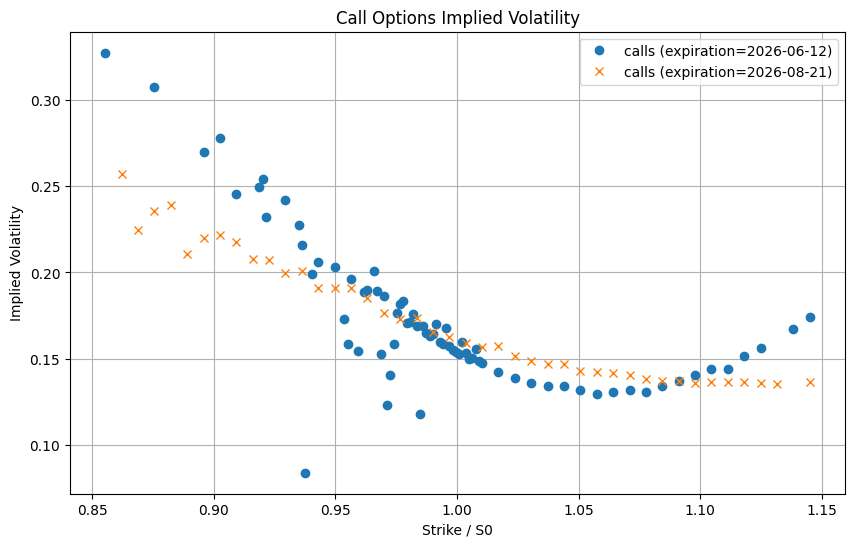

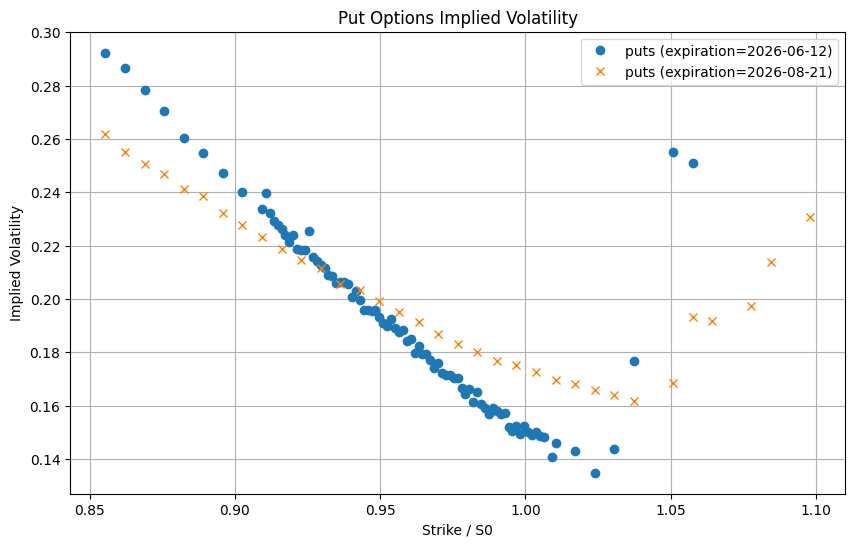

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(calls_1M_near["strike"] / S0, calls_1M_near["iv_calc"], 'o', label=f'calls (expiration={expiry_1M})')
plt.plot(calls_3M_near["strike"] / S0, calls_3M_near["iv_calc"], 'x', label=f'calls (expiration={expiry_3M})')
plt.title(f"Call Options Implied Volatility")
plt.xlabel("Strike / S0")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.show()

print("\n")

plt.figure(figsize=(10, 6))
plt.plot(puts_1M_near["strike"] / S0, puts_1M_near["iv_calc"], 'o', label=f'puts (expiration={expiry_1M})')
plt.plot(puts_3M_near["strike"] / S0, puts_3M_near["iv_calc"], 'x', label=f'puts (expiration={expiry_3M})')
plt.title(f"Put Options Implied Volatility")
plt.xlabel("Strike / S0")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.show()